In [1]:
#from UniSimCompressorData import UniSimCompressorData
from testcompressordata import testcompressordata
import matplotlib.pyplot as plt
import math
import numpy as np

In [2]:
# Initialize UniSim connection
unisim_path = r"C:\Users\sahm\Downloads\1_Sugg\1.usc"
extract_data = testcompressordata(unisim_path)

In [3]:
# Retrieve operations for a subflowsheet
print("\n--- Existing Operations ---")
print(extract_data["TPL13"])  #


--- Existing Operations ---
['MIX-26-06-01', '26HJ601', '26VG601', 'T-KA601', '26FV6019', 'MIX-26-06-2', '26HJ602', '26VG602', 'T-KA602', 'RCY-6-2', '26FV6048', '26HJ604', '20LV6018', '26LV6047', '26KA601', '26KA602', 'RCY-6', 'ADJ-1', 'VLV-100', 'Surge control 26KA601/602']


In [4]:
head, flow = extract_data.display_results("23KA502")


--- Compressor Head & Flow Data ---
1: 6880: Head (m) = [74.0655, 73.575, 69.651, 63.765, 57.879], Flow (ACT m³/h) = [1547.0, 1645.0, 1975.0000000000002, 2304.0, 2501.0]


2: 8846: Head (m) = [122.625, 120.663, 115.2675, 109.90143, 98.1, 86.328], Flow (ACT m³/h) = [2304.0, 2633.0, 2962.0, 3291.0, 3620.0, 3883.0000000000005]


3: 9829: Head (m) = [147.6405, 145.92375, 141.7545, 132.435, 119.682, 105.4575], Flow (ACT m³/h) = [3061.0, 3291.0, 3620.0, 3949.0, 4278.0, 4476.0]


4: 6894 rpm old: Head (m) = [65.99999999826, 65.00000000007, 62.499999999690004, 60.50000000331], Flow (ACT m³/h) = [1400.0, 1500.0, 1690.0, 1780.0]


5: 7878 rpm old: Head (m) = [88.19999999928001, 86.99999999949, 83.99999999511, 78.50000000016001, 77.50000000197001], Flow (ACT m³/h) = [1600.0, 1750.0, 2000.0, 2250.0, 2300.0]


6: 8853 rpm old: Head (m) = [114.00000002910001, 112.50000001709999, 109.99999999709999, 105.9999999651, 100.5000000192, 94.50000000063001], Flow (ACT m³/h) = [1849.9999999999998, 2000.0, 22

In [5]:
#------------------------------------------------------
#                    INPUT
#------------------------------------------------------


head_values_list = [
    [78.63, 76.12, 67.97, 55.42], 
    [103.72, 99.33, 90.23, 73.61, 71.42],
    [131.0, 130.38, 125.67, 115.95, 98.39, 88.98],
    [160.17, 159.86, 155.15, 145.43, 128.49, 105.91],
    [175.22, 173.97, 167.07, 154.53, 125.67, 115.64]    
]


flow_values_list = [
    [7939.62, 9119.90, 11399.87, 13437.01], 
    [9079.4, 11399.8, 13679.8, 15959.8, 16175.7],
    [10873.7, 11399.9, 13679.8, 15959.8, 18239.8, 18968.3],
    [13423.6, 13679.8, 15959.8, 18239.8, 20506.3, 21868.9],
    [15150.3, 15959.8, 18239.8, 20506.3, 22786.3, 23244.9]    
]

etta_values_list = [
    [0.8388, 0.8518, 0.8455, 0.7892],
    [0.8274, 0.8509, 0.8445, 0.7864, 0.7753],
    [0.8181, 0.8251, 0.8439, 0.8413, 0.7988, 0.7616],
    [0.8131, 0.8156, 0.8324, 0.8328, 0.8077, 0.7353],
    [0.8124, 0.8188, 0.8286, 0.8210, 0.8210, 0.7562, 0.7241]
]

rpm_values=[6503, 7432, 8361, 9290, 9755]


# Input
P_in = 23.2          # Suction Pressure (barA)
T_in = 273 + 23.7    # Inlet Temperature (K)
gamma = 1.309        # Heat capacity ratio from unisim
M = 21.64
Zave = (0.9330)/1
R = 8.314

#-------------------------------------------------------------------------
#    plot dashed line (What Wood read from performance curve
#-------------------------------------------------------------------------
head_values_list2 = [
    [79.31, 77.60, 67.70, 62.59, 55.78], 
    [104.44, 103.07, 90.26, 80.38, 71.19],
    [131.08, 130.22, 115.88, 104.30, 88.64],
    [160.10, 158.37, 144.04, 130.08, 105.93],
    [175.87, 172.62, 157.95, 138.20, 115.76]    
]

flow_values_list2 = [
    [174686.40, 191700.96, 252061.48, 274859.74, 294451.40], 
    [199034.04, 218615.73, 300165.61, 334688.01, 354765.49],
    [238464.49, 261575.92, 353399.66, 389369.54, 416038.76],
    [295222.98, 324434.41, 406629.03, 447417.83, 479559.13],
    [332105.60, 365171.48, 439984.41, 486240.30, 510033.25]    
]



rpm_values2=[6503, 7432, 8361, 9290, 9755]

<div class="alert alert-block alert-success">
<b> </b> 
Convert Head (m) vs Flow (ACT_m3/hr) to Pout (barA) vs Flow (Sm3/hr)
</div>

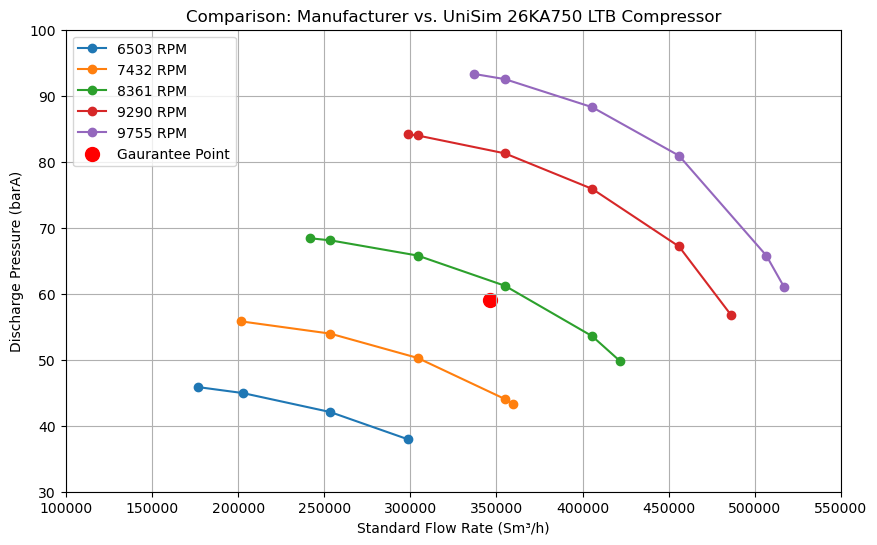

In [6]:
#def act_vol_flow_to_standard_vol_flow(P_in, T_in, R, gamma, Zave, M, head_values_list, flow_values_list, etta_values_list, rpm_values):
"""
Function to compute discharge pressure (barA) and standard volume flow (Sm³/h)
for multiple sets of head and flow values, then plot the results.
"""    
# Standard conditions
P_standard = 1.01325  # barA (standard pressure)
T_standard = 288.15  # K (standard temperature)

# Lists to store computed values
list_of_P_out_values = []
list_of_flow_std_m3_hr = []

# Compute discharge pressure and standard flow for each set
for head_values, flow_values, etta_values in zip(head_values_list, flow_values_list, etta_values_list):
    ratio = [1 + (((gamma - 1) / gamma)* (1/1)) * H * (M/(Zave * R * T_in)) for H in head_values]
    P_out_values = [(P_in) * (r ** ((gamma / (gamma - 1)) * 1)) for r in ratio]            
    flow_std_m3_hr = [F * (P_in / P_standard) * (T_standard / T_in) for F in flow_values]
        
        
    # Compute discharge pressure considering efficiency
#for head_values, flow_values, etta_values in zip(head_values_list, flow_values_list, etta_values_list):
    #ratio = [1 + (((gamma - 1) / gamma)* (1/etta)) * H * (M/(Zave * R * T_in)) for H, etta in zip(head_values, etta_values)]
    #P_out_values = [(P_in) * (r ** ((gamma / (gamma - 1)) * etta)) for r, etta in zip(ratio, etta_values)]            
    #flow_std_m3_hr = [F * (P_in / P_standard) * (T_standard / T_in) for F in flow_values]
        
        
    list_of_P_out_values.append(P_out_values)
    list_of_flow_std_m3_hr.append(flow_std_m3_hr)

# Plot the results
plt.figure(figsize=(10, 6))

for flow_std, P_out, rpm in zip(list_of_flow_std_m3_hr, list_of_P_out_values, rpm_values):
    plt.plot(flow_std, P_out, marker='o', linestyle='-', label=f"{rpm} RPM")
    
    
#-------------------------------------------------
#     Plot Gaurantee Point
#-------------------------------------------------
        
plt.scatter(346533.31, 59, color='red', marker='o', s=100, label="Gaurantee Point")


plt.xlabel("Standard Flow Rate (Sm³/h)")
plt.ylabel("Discharge Pressure (barA)")
plt.title("Comparison: Manufacturer vs. UniSim 26KA750 LTB Compressor")
plt.xlim(100000, 550000)
xticks = np.arange(100000, 550001, 50000)
plt.xticks(xticks)
plt.ylim(30, 100)
yticks = np.arange(30, 101, 10)
plt.yticks(yticks)
plt.grid(True)


#-------------------------------------------------
#     ADD surge and stone wall
#-------------------------------------------------

surge_points = [(list_of_flow_std_m3_hr[i][0], list_of_P_out_values[i][0]) for i in range(len(rpm_values))]
stone_wall_points = [(list_of_flow_std_m3_hr[i][-1], list_of_P_out_values[i][-1]) for i in range(len(rpm_values))]
        
# Add dashed lines for surge and stone wall
surge_x, surge_y = zip(*surge_points)  # Unpack start points
stone_x, stone_y = zip(*stone_wall_points)  # Unpack end points

#plt.plot(surge_x, surge_y, 'r--', linewidth=2, label="Surge Line")  # Dashed red line
#plt.plot(stone_x, stone_y, 'b--', linewidth=2, label="Stone Wall")  # Dashed blue line

plt.legend()


#plt.savefig("26KA750-LTB Compressor-2.png", dpi=300, bbox_inches='tight')  # Save as PNG



    

    #return list_of_P_out_values, list_of_flow_std_m3_hr

#list_of_P_out_values, list_of_flow_std_m3_hr = act_vol_flow_to_standard_vol_flow(
#    P_in, T_in, R, gamma, Zave, M, head_values_list, flow_values_list, etta_values_list, rpm_values
#)

In [1]:
  "
# Lists to store computed values
list_of_P_out_values = []
list_of_flow_std_m3_hr = []

list_of_P_out_values2 = []
list_of_flow_std_m3_hr2 = []

# Compute discharge pressure and standard flow for each set
for head_values, flow_values, etta_values in zip(head_values_list, flow_values_list, etta_values_list):
    ratio = [1 + (((gamma - 1) / gamma)* (1/1)) * H * (M/(Zave * R * T_in)) for H in head_values]
    P_out_values = [(P_in) * (r ** ((gamma / (gamma - 1)) * 1)) for r in ratio]            
    flow_std_m3_hr = [F * (P_in / P_standard) * (T_standard / T_in) for F in flow_values]    
   
        
    list_of_P_out_values.append(P_out_values)
    list_of_flow_std_m3_hr.append(flow_std_m3_hr)
    

    
for head_values2, flow_values2 in zip(head_values_list2, flow_values_list2):
    ratio2 = [1 + (((gamma - 1) / gamma)) * HH * (M/(Zave * R * T_in)) for HH in head_values2]
    P_out_values2 = [(P_in) * (rr ** ((gamma / (gamma - 1)))) for rr in ratio2]
    flow_std_m3_hr2 = [FF for FF in flow_values2]  
    
    list_of_P_out_values2.append(P_out_values2)
    list_of_flow_std_m3_hr2.append(flow_std_m3_hr2)
    



# Plot connecting line

surge_points = [(list_of_flow_std_m3_hr2[i][0], list_of_P_out_values2[i][0]) for i in range(len(rpm_values))]
before_surge_points = [(list_of_flow_std_m3_hr2[i][1], list_of_P_out_values2[i][1]) for i in range(len(rpm_values))]
stone_wall_points = [(list_of_flow_std_m3_hr2[i][-1], list_of_P_out_values2[i][-1]) for i in range(len(rpm_values))]

surge_x, surge_y = zip(*surge_points)  # Unpack start points
bsurge_x, bsurge_y = zip(*before_surge_points)  
stone_x, stone_y = zip(*stone_wall_points)

# Plot the results
plt.figure(figsize=(10, 6))


for flow_std, P_out, rpm in zip(list_of_flow_std_m3_hr, list_of_P_out_values, rpm_values):
    plt.plot(flow_std, P_out, linestyle='-', label=f"{rpm} RPM")

    

for flow_std2, P_out2, rpm in zip(list_of_flow_std_m3_hr2, list_of_P_out_values2, rpm_values2):
    plt.plot(flow_std2, P_out2, linestyle='--')
    
    
plt.plot(surge_x, surge_y, 'r--', marker='o', linewidth=0.5, label="Surge Line")  # Dashed red line 
plt.plot(bsurge_x, bsurge_y, 'g--', marker='o', linewidth=0.5)  # Dashed red line
#plt.plot(stone_x, stone_y, 'k--', linewidth=0.5)

  
#-------------------------------------------------
#     Plot Gaurantee Point
#-------------------------------------------------
        
plt.scatter(346533.31, 59, color='red', marker='*', s=50, label="Gaurantee Point")


plt.xlabel("Standard Flow Rate (Sm³/h)")
plt.ylabel("Discharge Pressure (barA)")
plt.title("Comparison: Manufacturer vs. UniSim 26KA750 LTB Compressor")
plt.xlim(100000, 550000)
xticks = np.arange(100000, 550001, 50000)
plt.xticks(xticks)
plt.ylim(30, 100)
yticks = np.arange(30, 101, 10)
plt.yticks(yticks)
plt.grid(True)


#-------------------------------------------------
#     ADD surge and stone wall
#-------------------------------------------------

#surge_points = [(list_of_flow_std_m3_hr[i][0], list_of_P_out_values[i][0]) for i in range(len(rpm_values))]
#stone_wall_points = [(list_of_flow_std_m3_hr[i][-1], list_of_P_out_values[i][-1]) for i in range(len(rpm_values))]
        
# Add dashed lines for surge and stone wall
#surge_x, surge_y = zip(*surge_points)  # Unpack start points
#stone_x, stone_y = zip(*stone_wall_points)  # Unpack end points

#plt.plot(surge_x, surge_y, 'r--', linewidth=2, label="Surge Line")  # Dashed red line
#plt.plot(stone_x, stone_y, 'b--', linewidth=2, label="Stone Wall")  # Dashed blue line
plt.legend()
plt.savefig("26KA750-LTB Compressor-compare.png", dpi=300, bbox_inches='tight')  # Save as PNG
plt.show()

SyntaxError: unterminated string literal (detected at line 1) (3490029095.py, line 1)

In [8]:
head_values_list2 = [
    [79.31, 77.60, 67.70, 62.59, 55.78], 
    [104.44, 103.07, 90.26, 80.38, 71.19],
    [131.08, 130.22, 115.88, 104.30, 88.64],
    [160.10, 158.37, 144.04, 130.08, 105.93],
    [175.87, 172.62, 157.95, 138.20, 115.76]    
]

flow_values_list2 = [
    [174686.40, 191700.96, 252061.48, 274859.74, 294451.40], 
    [199034.04, 218615.73, 300165.61, 334688.01, 354765.49],
    [238464.49, 261575.92, 353399.66, 389369.54, 416038.76],
    [295222.98, 324434.41, 406629.03, 447417.83, 479559.13],
    [332105.60, 365171.48, 439984.41, 486240.30, 510033.25]    
]



rpm_values2=[6503, 7432, 8361, 9290, 9755]




<div class="alert alert-block alert-warning">
<b></b> 
unisim plot
</div>

In [9]:
def plot_heads_and_flows(head_values_list, flow_values_list, rpm_values):
    """
    Function to plot multiple head and flow value sets on the same axis,
    with each curve labeled according to its corresponding compressor RPM.
    First and last points are connected with straight lines.
    """
    plt.figure(figsize=(8, 6))

    first_points = []
    end_points = []

    # Plot each curve and label with its RPM value
    for head_values, flow_values, rpm in zip(head_values_list, flow_values_list, rpm_values):
        plt.plot(flow_values, head_values, marker='o', linestyle='-', label=f"{rpm} RPM")
        first_points.append((flow_values[0], head_values[0]))
        end_points.append((flow_values[-1], head_values[-1]))

    # Connect first points with a straight line
    first_x, first_y = zip(*first_points)
    plt.plot(first_x, first_y, linestyle='--', color='black', label="Surge Line")

    # Connect end points with a straight line
    end_x, end_y = zip(*end_points)
    plt.plot(end_x, end_y, linestyle='--', color='red', label="Stone Wall")

    plt.xlabel("Flow (ACT_m3/hr)")
    plt.ylabel("Head (m)")
    plt.title("Head vs Flow Plot")
    plt.legend()
    plt.grid(True)
    plt.show()

In [10]:
#------------------------------------------------------
#                    INPUT
#------------------------------------------------------
head_values_list = [
    [8017.9, 7762.1, 6930.6, 5651.4], 
    [10576.4, 10128.6, 9201.2, 7506.2, 7282.4],
    [13358.6, 13294.7, 12815, 11823.6, 10032.7, 9073.3],
    [16332.8, 16300.8, 15821.1, 14829.7, 13102.8, 10800.2],
    [17867.9, 17739.96, 17036.4, 15757.2, 12815, 11791.6]
    
]

flow_values_list = [
    [7927.7, 9119.9, 11399.8, 13437.0], 
    [9079.4, 11399.8, 13679.8, 15959.8, 16175.7],
    [10873.7, 11399.9, 13679.8, 15959.8, 18239.8, 18968.3],
    [13423.6, 13679.8, 15959.8, 18239.8, 20506.3, 21868.9],
    [15150.3, 15959.8, 18239.8, 20506.3, 22786.3, 23244.9]
    
]

rpm_values=[6503, 7432, 8361, 9290, 9755]

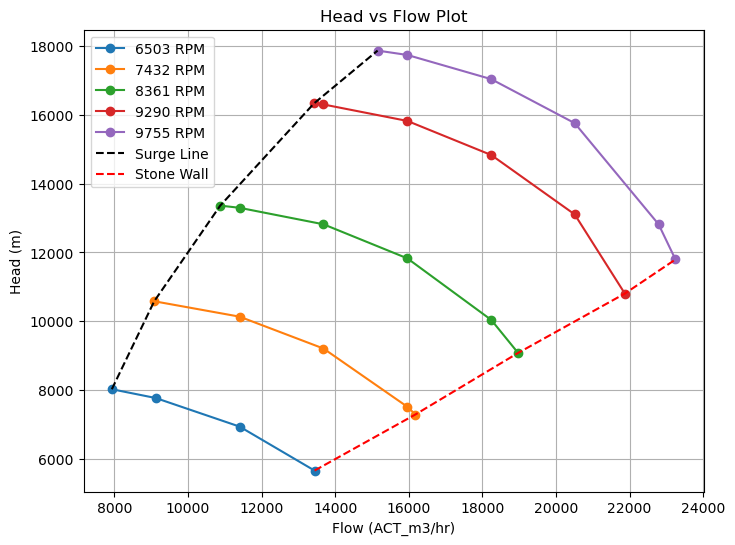

In [11]:
plot_heads_and_flows(head_values_list, flow_values_list, rpm_values)

# 26KA750

In [12]:
 "
#head_values_list = [
#    [8017.9, 7762.1, 6930.6, 5651.4], 
#    [10576.4, 10128.6, 9201.2, 7506.2, 7282.4],
#    [13358.6, 13294.7, 12815, 11823.6, 10032.7, 9073.3],
#    [16332.8, 16300.8, 15821.1, 14829.7, 13102.8, 10800.2],
#    [17867.9, 17739.96, 17036.4, 15757.2, 12815, 11791.6]
    
#]

head_values_list = [
    [78.63, 76.12, 67.97, 55.42], 
    [103.72, 99.33, 90.23, 73.61, 71.42],
    [131.0, 130.38, 125.67, 115.95, 98.39, 88.98],
    [160.17, 159.86, 155.15, 145.43, 128.49, 105.91],
    [175.22, 173.97, 167.07, 154.53, 125.67, 115.64]    
]


flow_values_list = [
    [7927.7, 9119.9, 11399.8, 13437.0], 
    [9079.4, 11399.8, 13679.8, 15959.8, 16175.7],
    [10873.7, 11399.9, 13679.8, 15959.8, 18239.8, 18968.3],
    [13423.6, 13679.8, 15959.8, 18239.8, 20506.3, 21868.9],
    [15150.3, 15959.8, 18239.8, 20506.3, 22786.3, 23244.9]    
]

rpm_values=[6503, 7432, 8361, 9290, 9755]

SyntaxError: unterminated string literal (detected at line 1) (1929504649.py, line 1)

# 27KA500

In [ ]:
 "
#head_values_list = [
#    [3293, 3180.1, 2954.3, 2562.8, 2028.4, 1682.1], 
#    [3624.2, 3563.9, 3353.2, 3006.9, 2510.1, 1847.7],
#    [4158.7, 4128.5, 3977.9, 3691.9, 3255.3, 2653.2, 2081.1], 
#    [5347.9, 5280.2, 5092.1, 4783.4, 4331.8, 3684.4, 2878.9, 2623.1],
#    [5995.3, 5972.8, 5829.7, 5573.8, 5197.4, 4640.4, 3910.3, 2961.8, 2924.2],
#    [6687.9, 6687.9, 6605.1, 6401.8, 6063.1, 5603.9, 4971.6, 4090.9, 3277.9], 
#    [7418, 7387.9, 7229.8, 6958.9, 6567.49, 6025.5, 5265.2, 4211.3, 3669.4], 
#    [8170.8, 8170.8, 8080.48, 7869.7, 7523.4, 7071.8, 6439.5, 5491.0, 4181.2, 4015.6]
#]

head_values_list = [
    [32.29, 31.19, 28.97, 25.13, 19.89, 16.5], 
    [35.54, 34.95, 32.88, 29.49, 24.62, 18.12],
    [40.78, 40.49, 39.01, 36.21, 31.92, 26.02, 20.41],
    [52.45, 51.78, 49.94, 46.91, 42.48, 36.13, 28.23, 25.72],
    [58.79, 58.57, 57.17, 54.66, 50.97, 45.51, 38.35, 29.05, 28.68],
    [65.59, 65.59, 64.77, 62.78, 59.46, 54.96, 48.75, 40.12, 32.15],
    [72.75, 72.45, 70.90, 68.24, 64.40, 59.09, 51.63, 41.30, 35.98],
    [80.13, 80.13, 79.24, 77.18, 73.78, 69.35, 63.15, 53.85, 41.00, 39.38]
    
]

flow_values_list = [
    [1599.8, 2001.8, 2401.6, 2801.4, 3201.3, 3410.9], 
    [1677.6, 1999.6, 2401.6, 2801.4, 3201.2, 3598.9],
    [1798.6, 1997.5, 2401.6, 2801.4, 3201.3, 3598.9, 3901.5],
    [2049.3, 2401.6, 2801.4, 3203.4, 3598.9, 4003.1, 4400.7, 4508.8],
    [2200.6, 2401.6, 2801.4, 3201.3, 3598.9, 4003.1, 4400.7, 4800.5, 4815.7],
    [2367, 2401.6, 2801.4, 3203.4, 3598.9, 4003.1, 4400.7, 4800.5, 5103.1],
    [2544.3, 2801.4, 3201.3, 3598.93, 4003.1, 4400.7, 4800.5, 5200.4, 5373.3],
    [2721.5, 2801.4, 3203.4, 3598.9, 4003.0, 4400.8, 4800.5, 5200.4, 5602.3, 5645.6]    
]

rpm_values=[8200, 8609, 9224, 10453, 11068, 11683, 12298, 12913]


P_in = 57.4          # Suction Pressure (barA)
T_in = 273 + 26.7   # Inlet Temperature (K)
gamma = 1.503      # Heat capacity ratio from unisim
M = 21.3
Zave = 0.83 # inlet stream Z
R = 8.314

# 23KA500-recompression

In [ ]:
  "
head_values_list = [
    [51.3, 49.03, 47.37], 
    [69.87, 66.19, 61.29],
    [90.71, 85.81, 76.00], 
    [112.78, 105.91, 88.26],
    [122.58, 117.68, 93.71]
]

flow_values_list = [ 
    [5730.05, 6312.45, 6656.97],
    [6700.0, 8000.0, 8800.0],
    [7650.0, 9700.0, 11370.0],
    [9400.0, 12000.0, 14000.0],
    [10700.0, 13000.0, 15100.0]      
]

rpm_values=[4421, 5053, 5684, 6316, 6632]

# 23KA501

In [ ]:
  "
head_values_list = [
    [38.5, 36.52, 32.67], 
    [51.98, 47.07, 41.19],
    [66.69, 61.78, 49.03], 
    [82.87, 74.53, 57.86],
    [91.2, 82.38, 61.78]
]

    
flow_values_list = [ 
    [1318.74, 1499.64, 1753.77],
    [1475.0, 1949.9, 2250.0],
    [1640.0, 2250.0, 2840.0],
    [1910.0, 2850.0, 3475.0],
    [2190.0, 3125.0, 3800.0]      
]

rpm_values=[4421, 5053, 5684, 6316, 6632]

# 23KA502

In [ ]:
  "
#head_values_list = [
#    [7452.55, 7137.23, 6471.53, 6121.17], 
#    [9905.11, 9852.55, 9449.64, 8818.98, 7715.33, 7487.59],
#    [12550.36, 12462.77, 12112.41, 11534.31, 10658.39, 9169.34], 
#    [15335.77, 15090.51, 14600.0, 13829.20, 12550.36, 10921.17],
#    [16754.74, 16474.45, 15913.87, 15020.44, 13496.35, 11849.64]     
#]

head_values_list = [
    [73.08, 69.99, 63.46, 60.03], 
    [97.14, 96.62, 92.67, 86.48, 75.66, 73.43],
    [123.08, 122.22, 118.78, 113.11, 104.52, 89.92], 
    [150.39, 147.99, 143.18, 135.62, 123.08, 107.10],
    [164.31, 161.56, 156.06, 147.30, 132.35, 116.21]     
]

flow_values_list = [     
    [1534.41, 1803.50, 2163.01, 2296.48],
    [1723.85, 1803.50, 2163.01, 2524.67, 2884.17, 2929.38],
    [2003.71, 2163.01, 2524.67, 2886.32, 3245.83, 3611.79],
    [2610.77, 2884.17, 3245.83, 3605.33, 3966.99, 4259.76],
    [2989.65, 3245.83, 3605.33, 3964.84, 4326.49, 4565.45]      
]

rpm_values=[6880, 7863, 8846, 9829, 10320]

# 26KA601

In [ ]:
  "
#head_values_list = [
#    [10750.0, 10500.0, 10250.0, 10000.0, 9500.0, 9000.0, 8500.0, 8000.0],  
#    [12250.0, 12000.0, 11750.0, 11500.0, 11250.0, 11000.0, 10500.0, 10000.0, 9000.0],
#    [13750.0, 13500.0, 13250.0, 13000.0, 12500.0, 12000.0, 11500.0, 11000.0, 10000.0], 
#    [15300.0, 15250.0, 15000.0, 14750.0, 14500.0, 14000.0, 13500.0, 12500.0, 12000.0],
#    [17000.0, 16750.0, 16500.0, 16000.0, 15500.0, 15000.0, 14500.0, 13500.0, 12500.0],
#    [18600.0, 18550.0, 18500.0, 18000.0, 17500.0, 17000.0, 15500.0, 14500.0, 13000.0],   
#]

head_values_list = [
    [105.42, 102.97, 100.52, 98.07, 93.16, 88.26, 83.36, 78.45],  
    [120.13, 117.68, 115.23, 112.78, 110.32, 107.87, 102.97, 98.07, 88.26],
    [134.84, 132.39, 129.94, 127.49, 122.58, 117.68, 112.78, 107.87, 98.07], 
    [150.04, 149.55, 147.10, 144.65, 142.20, 137.29, 132.39, 122.58, 117.68],
    [166.71, 164.26, 161.81, 156.91, 152.00, 147.10, 142.20, 132.39, 122.58],
    [182.4, 181.91, 181.42, 176.52, 171.62, 166.71, 152.00, 142.20, 127.49]   
]

flow_values_list = [     
    [3300.0, 3800.0, 4200.0, 4500.0, 4900.0, 5200.0, 5500.0, 5700.0],
    [3500.0, 4000.0, 4400.0, 4700.0, 5000.0, 5200.0, 5500.0, 5800.0, 6200.0],
    [3699.9, 4400.0, 4800.0, 5100.0, 5550.0, 5900.0, 6150.0, 6400.0, 6700.0],
    [4100.0, 4500.0, 5000.0, 5300.0, 5600.0, 6000.0, 6300.0, 6800.0, 7250.0],
    [4550.0, 5200.0, 5600.0, 6100.0, 6500.0, 6800.0, 7000.0, 7399.9, 7650.0],
    [5100.0, 5300.0, 5500.0, 6400.0, 6800.0, 7100.0, 7700.0, 8000.0, 8200.0]    
]

rpm_values=[7432, 7897, 8361, 8826, 9290, 9755]


#----------INPUT--------------
P_in = 52          # Suction Pressure (barA)
T_in = 273 + 27   # Inlet Temperature (K)
gamma = 1.480    # Heat capacity ratio from unisim
M = 21.57
Zave = 0.8429 #(0.8518+0.8717)/2
R = 8.314

# 26KA602

In [ ]:
   "     
head_values_list = [
    [72.94, 72.32, 71.10, 68.65, 66.19, 63.74, 61.29, 53.94, 51.48],  
    [82.38, 80.90, 78.45, 76.00, 73.55, 71.10, 66.19, 61.29, 56.39],
    [93.16, 90.71, 88.26, 85.81, 83.36, 78.45, 71.10, 67.18, 63.74], 
    [104.20, 102.97, 100.52, 95.61, 93.16, 88.26, 80.90, 68.65],
    [115.23, 112.78, 110.32, 105.42, 95.61, 88.26, 83.36, 78.45],
    [127.49, 125.03, 122.58, 120.13, 114.00, 105.42, 98.07, 90.71, 83.36]   
]

flow_values_list = [     
    [974.9, 1050.0, 1100.0, 1250.0, 1400.0, 1500.0, 1575.0, 1775.0, 1849.9],
    [1025.0, 1175.0, 1300.0, 1450.0, 1550.0, 1637.0, 1800.0, 1900.0, 2000.0],
    [1100.0, 1250.0, 1400.0, 1525.0, 1637.0, 1800.0, 2000.0, 2100.0, 2150.0],
    [1170.0, 1250.0, 1400.0, 1637.0, 1750.0, 1900.0, 2100.0, 2300.0],
    [1250.0, 1450.0, 1550.0, 1750.0, 2075.0, 2250.0, 2350.0, 2425.0],
    [1325.0, 1500.0, 1600.0, 1750.0, 1949.9, 2225.0, 2375.0, 2500.0, 2600.0]    
]

rpm_values=[7432, 7897, 8361, 8826, 9290, 9755]


#----------INPUT--------------
P_in = 171.57          # Suction Pressure (barA)
T_in = 273 + 40   # Inlet Temperature (K)
gamma = 1.899   # Heat capacity ratio from unisim
M = 21.57
Zave = 0.7202 #(0.8518+0.8717)/2
R = 8.314


#----------Plot adjustmnts--------------------
#plt.title("Comparison: Manufacturer vs. UniSim - 26KA602")
#plt.xlim(750, 2750)
# xticks = np.arange(750, 2751, 250)
# plt.xticks(xticks)
# plt.ylim(250, 550)
# yticks = np.arange(250, 551, 50)
# plt.yticks(yticks)
# plt.grid(True)